
# 06 &nbsp;|&nbsp; Interpretability and Dose / Exposure Analysis

**Dissertation:** *Temporal Prediction of In-Trial Adverse Events in Oncology Clinical Trials Using Machine Learning*

---

## Purpose

This notebook covers the **Dose & Interpretability Analysis** phase of the project plan
(11–25 July 2026) and the corresponding dissertation objectives:

* *"to incorporate basic treatment exposure and dose-related features as auxiliary predictors"*
* *"to apply interpretability techniques to explain model predictions and assess their clinical plausibility"*

Osterman et al. argue that oncology risk models frequently fail not on discrimination but
on **implementation** — clinicians will not act on a score they cannot interrogate. The
analyses below are therefore not decoration; they are the test of whether the model has
learned oncology or has learned an artefact.

| Section | Method |
|---|---|
| 1 | Global feature importance — SHAP + permutation importance |
| 2 | Feature-block attribution |
| 3 | Dependence: how each key predictor moves risk |
| 4 | Dose and exposure sub-analysis |
| 5 | Individual patient explanations |
| 6 | Clinical plausibility assessment |
| 7 | Limitations |

In [1]:
# --- environment setup -------------------------------------------------------
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aeprep import io, quality, labels, features_static, features_temporal
from aeprep import modeling, evaluation, plots
from aeprep.config import CFG, DATASET_DIR, FIGURE_DIR, TABLE_DIR, MODEL_DIR, ensure_output_dirs

ensure_output_dirs()
plots.set_style()
pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print(f"project root : {PROJECT_ROOT}")
print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"analysis config: horizon={CFG.prediction_horizon_days}d, "
      f"grade>={CFG.severity_threshold}, landmark step={CFG.landmark_step_days}d")

project root : C:\BITS M Tech\Sem 4 Dissertation\Sem 4 Dissertation\ProjectWork\project-root
pandas 2.3.3 | numpy 2.3.5
analysis config: horizon=30d, grade>=3, landmark step=14d


In [2]:
import joblib
import shap

art = joblib.load(MODEL_DIR / "temporal_landmark_model.joblib")
model = art["model"]
best_name = art["best_name"]

landmark = pd.read_parquet(DATASET_DIR / "landmark_analytic_dataset.parquet")
comparison = pd.read_parquet(DATASET_DIR / "landmark_test_predictions.parquet")

X_all = landmark[art["feature_columns"]]
y_all = landmark["y"]
g_all = landmark["PID"]

train_mask = g_all.isin(art["train_pids"])
X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test, y_test = X_all[~train_mask], y_all[~train_mask]

print(f"Model            : {best_name}")
print(f"Training rows    : {len(X_train):,} ({X_train.shape[1]} features)")
print(f"Held-out rows    : {len(X_test):,}")
print(f"shap {shap.__version__}")

Model            : Random Forest
Training rows    : 3,773 (378 features)
Held-out rows    : 1,883
shap 0.52.0



## 1. Global feature importance

### 1.1 SHAP values

SHAP (Lundberg & Lee, 2017) attributes each prediction additively to its features, giving
both a global ranking and a per-patient explanation from the same computation.

In [3]:
prep = model.named_steps["prep"]
clf = model.named_steps["clf"]

X_test_enc = pd.DataFrame(prep.transform(X_test),
                          columns=prep.get_feature_names_out(),
                          index=X_test.index)
X_train_enc = pd.DataFrame(prep.transform(X_train),
                           columns=prep.get_feature_names_out(),
                           index=X_train.index)

sample = X_test_enc.sample(min(700, len(X_test_enc)), random_state=CFG.random_state)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(sample, check_additivity=False)

# Binary tree ensembles return either a list (per class) or a 3-D array.
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif getattr(shap_values, "ndim", 2) == 3:
    shap_values = shap_values[:, :, 1]

print(f"SHAP values computed for {sample.shape[0]} held-out rows "
      f"x {sample.shape[1]} encoded features")

SHAP values computed for 700 held-out rows x 580 encoded features


findfont: Failed to find font weight semibold, now using 700.


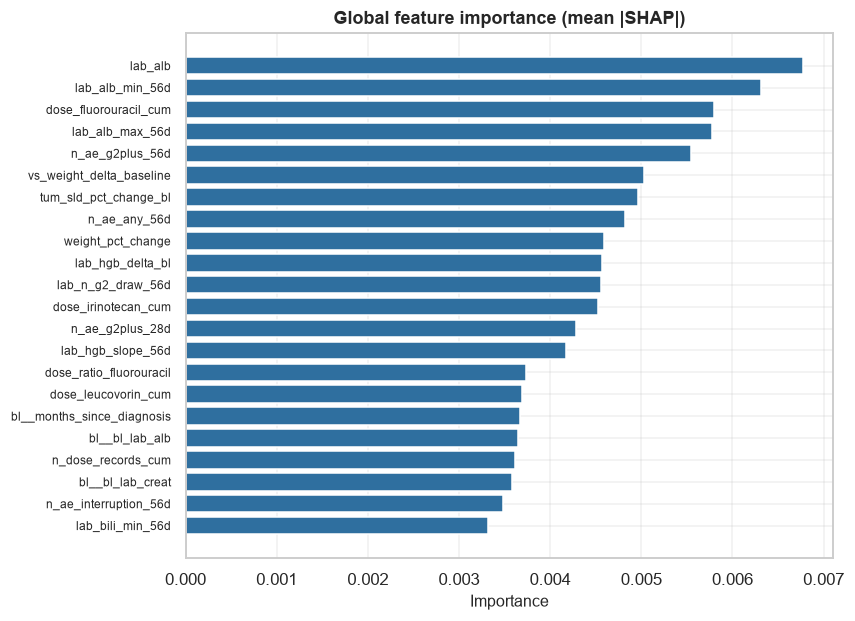

,mean_abs_shap
lab_alb,0.0068
lab_alb_min_56d,0.0063
dose_fluorouracil_cum,0.0058
lab_alb_max_56d,0.0058
n_ae_g2plus_56d,0.0055
vs_weight_delta_baseline,0.0050
tum_sld_pct_change_bl,0.0050
n_ae_any_56d,0.0048
weight_pct_change,0.0046
lab_hgb_delta_bl,0.0046


In [4]:
mean_abs = pd.Series(np.abs(shap_values).mean(axis=0), index=sample.columns)
mean_abs = mean_abs.sort_values(ascending=False)
mean_abs.to_frame("mean_abs_shap").to_csv(TABLE_DIR / "06_shap_importance.csv")

fig, ax = plt.subplots(figsize=(7.6, 6.2))
plots.plot_feature_importance(mean_abs, top_n=22,
                              title="Global feature importance (mean |SHAP|)", ax=ax)
plots.save(fig, "06_shap_importance")
plt.show()

mean_abs.head(20).to_frame("mean_abs_shap")

findfont: Failed to find font weight semibold, now using 700.


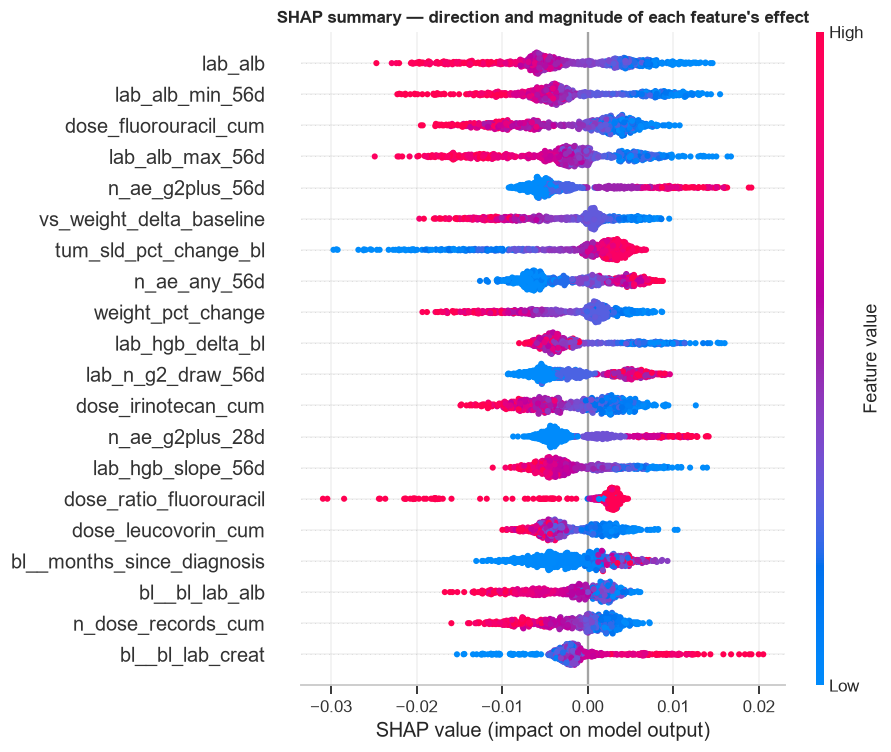

In [5]:
fig = plt.figure(figsize=(8.5, 7.0))
shap.summary_plot(shap_values, sample, max_display=20, show=False, plot_size=None)
plt.title("SHAP summary — direction and magnitude of each feature's effect", fontsize=11)
plt.tight_layout()
plots.save(fig, "06_shap_summary")
plt.show()


### 1.2 Permutation importance

SHAP measures how much a feature *moves the model*. Permutation importance measures how
much the model *needs* it — the drop in held-out AUROC when the feature is shuffled. The
two answer different questions and agreement between them is reassuring.

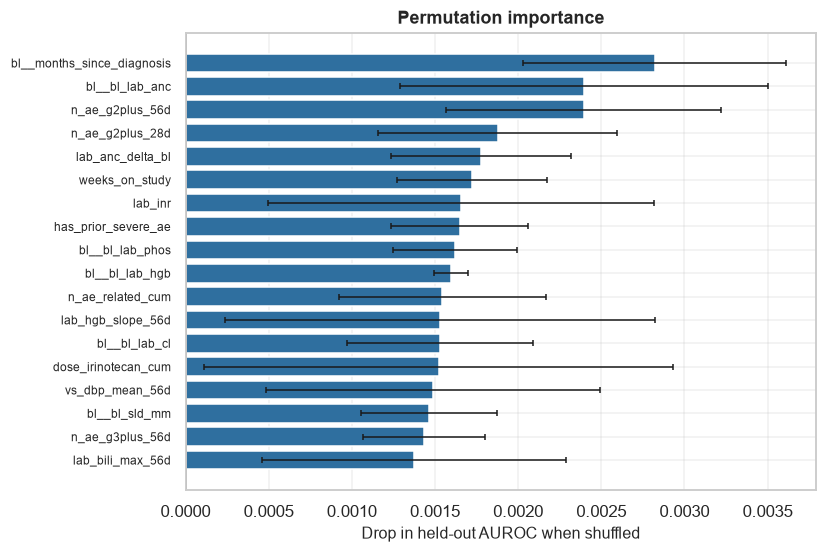

,feature,auroc_drop,std
0,bl__months_since_diagnosis,0.0028,0.0008
1,bl__bl_lab_anc,0.0024,0.0011
2,n_ae_g2plus_56d,0.0024,0.0008
3,n_ae_g2plus_28d,0.0019,0.0007
4,lab_anc_delta_bl,0.0018,0.0005
5,weeks_on_study,0.0017,0.0004
6,lab_inr,0.0017,0.0012
7,has_prior_severe_ae,0.0016,0.0004
8,bl__bl_lab_phos,0.0016,0.0004
9,bl__bl_lab_hgb,0.0016,0.0001


In [6]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score, make_scorer

# Permutation importance is expensive (one refit-free re-scoring per feature per repeat),
# so it is computed on a random subsample of the held-out rows.
perm_idx = np.random.default_rng(CFG.random_state).choice(
    len(X_test), size=min(900, len(X_test)), replace=False)
X_perm, y_perm = X_test.iloc[perm_idx], y_test.iloc[perm_idx]

perm = permutation_importance(
    model, X_perm, y_perm, n_repeats=5, random_state=CFG.random_state,
    scoring=make_scorer(roc_auc_score, response_method="predict_proba"), n_jobs=-1)

perm_tbl = (pd.DataFrame({"feature": X_test.columns,
                          "auroc_drop": perm.importances_mean,
                          "std": perm.importances_std})
              .sort_values("auroc_drop", ascending=False))
perm_tbl.to_csv(TABLE_DIR / "06_permutation_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(7.4, 5.4))
top = perm_tbl.head(18).iloc[::-1]
ax.barh(top["feature"], top["auroc_drop"], xerr=top["std"],
        color=plots.PALETTE[0], error_kw={"lw": 1, "capsize": 2})
ax.axvline(0, c="k", lw=1.2)
ax.set(xlabel="Drop in held-out AUROC when shuffled",
       title="Permutation importance")
ax.tick_params(axis="y", labelsize=8)
plots.save(fig, "06_permutation_importance")
plt.show()

perm_tbl.head(15).reset_index(drop=True)


## 2. Where does the signal live? Attribution by feature block

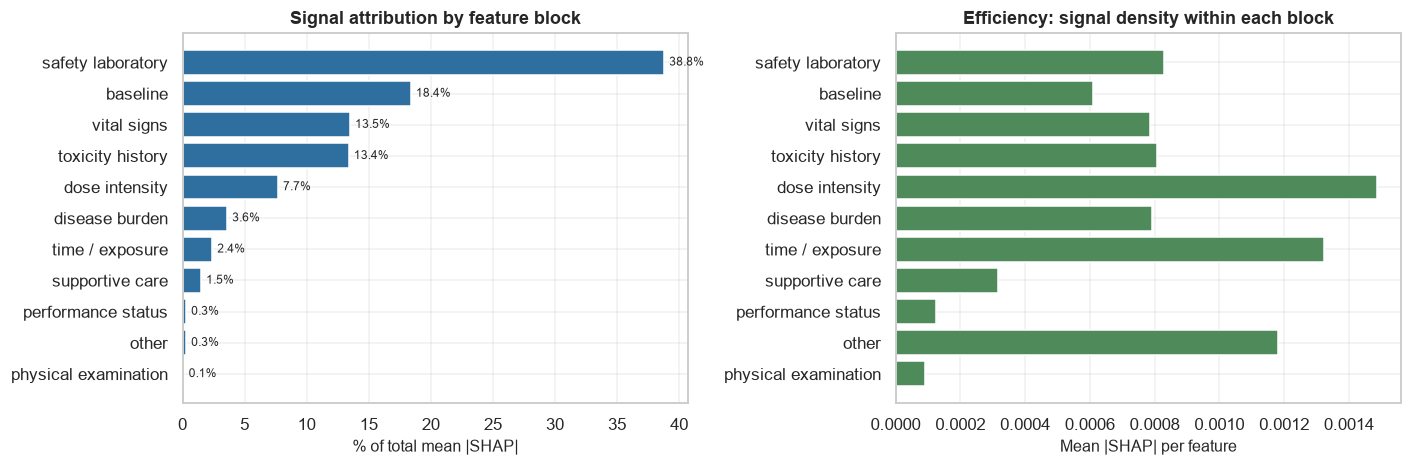

,total_shap,n_features,pct_of_total
block,,,
safety laboratory,0.1723,208,38.8000
baseline,0.0818,134,18.4000
vital signs,0.0597,76,13.5000
toxicity history,0.0597,74,13.4000
dose intensity,0.0342,23,7.7000
disease burden,0.0159,20,3.6000
time / exposure,0.0106,8,2.4000
supportive care,0.0066,21,1.5000
performance status,0.0014,11,0.3000


In [7]:
def block_of(col: str) -> str:
    col = col.replace("missingindicator_", "")
    if col.startswith("bl__"):
        return "baseline"
    if col in ("time_on_study", "weeks_on_study", "cycle_number",
               "days_since_last_dose", "n_dose_records_cum", "n_dose_records_28d"):
        return "time / exposure"
    if col.startswith(("dose_", "rdi_", "no_recent_dose")):
        return "dose intensity"
    if col.startswith("ecog"):
        return "performance status"
    if col.startswith(("vs_", "weight_pct")):
        return "vital signs"
    if col.startswith(("n_ae", "n_severe", "days_since_last", "max_grade_so_far",
                       "n_distinct_pt", "has_prior", "last_ae_grade")):
        return "toxicity history"
    if col.startswith(("n_conmed", "conmed_")):
        return "supportive care"
    if col.startswith("pe_"):
        return "physical examination"
    if col.startswith("lab_"):
        return "safety laboratory"
    if col.startswith("tum_"):
        return "disease burden"
    return "other"

block_attr = (mean_abs.rename_axis("feature").reset_index(name="mean_abs_shap")
              .assign(block=lambda d: d["feature"].map(block_of))
              .groupby("block")
              .agg(total_shap=("mean_abs_shap", "sum"),
                   n_features=("feature", "size"))
              .sort_values("total_shap", ascending=False))
block_attr["pct_of_total"] = (100 * block_attr["total_shap"]
                              / block_attr["total_shap"].sum()).round(1)
block_attr.to_csv(TABLE_DIR / "06_block_attribution.csv")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))
b = block_attr.iloc[::-1]
axes[0].barh(b.index, b["pct_of_total"], color=plots.PALETTE[0])
axes[0].set(xlabel="% of total mean |SHAP|", title="Signal attribution by feature block")
for i, v in enumerate(b["pct_of_total"]):
    axes[0].text(v + 0.4, i, f"{v:.1f}%", va="center", fontsize=8)

axes[1].barh(b.index, b["total_shap"] / b["n_features"], color=plots.PALETTE[2])
axes[1].set(xlabel="Mean |SHAP| per feature",
            title="Efficiency: signal density within each block")
fig.tight_layout()
plots.save(fig, "06_block_attribution")
plt.show()

block_attr


## 3. Dependence — how each key predictor moves the risk

A SHAP dependence plot shows the fitted functional form. This is where clinical
plausibility is actually assessed: does the model's response to a feature match what an
oncologist would expect?

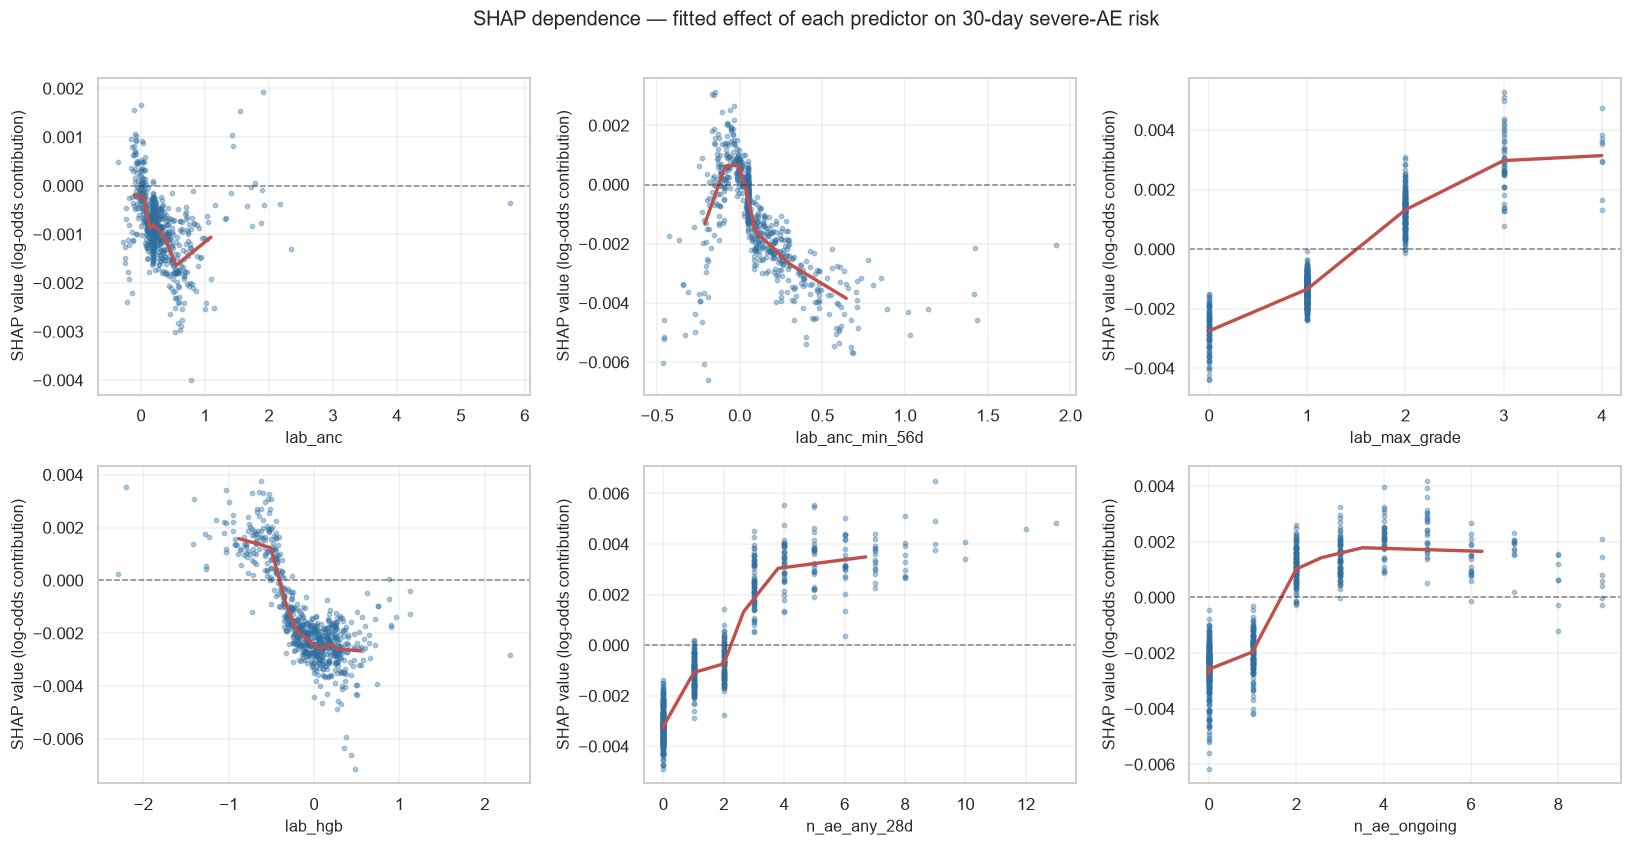

In [8]:
candidates = ["lab_anc", "lab_anc_min_56d", "lab_max_grade", "lab_hgb", "n_ae_any_28d", "n_ae_ongoing", "n_ae_g2plus_28d", "n_conmed_active",
              "days_since_last_ae", "rdi_fluorouracil", "ecog_current",
              "time_on_study", "vs_weight", "n_ae_cl_haematologic_cum"]
present = [c for c in candidates if c in sample.columns][:6]
if len(present) < 6:
    present += [c for c in mean_abs.head(10).index if c not in present][:6 - len(present)]

fig, axes = plt.subplots(2, 3, figsize=(15.0, 7.6))
for ax, feat in zip(axes.ravel(), present):
    j = list(sample.columns).index(feat)
    ax.scatter(sample[feat], shap_values[:, j], s=8, alpha=0.35, color=plots.PALETTE[0])
    # LOWESS-free trend: bin the x-axis and plot the mean SHAP per bin.
    dfp = pd.DataFrame({"x": sample[feat].to_numpy(), "s": shap_values[:, j]})
    if dfp["x"].nunique() > 8:
        dfp["bin"] = pd.qcut(dfp["x"].rank(method="first"), 10, labels=False)
        tr = dfp.groupby("bin").agg(x=("x", "mean"), s=("s", "mean"))
    else:
        tr = dfp.groupby("x").agg(s=("s", "mean")).reset_index()
    ax.plot(tr["x"], tr["s"], lw=2.2, color=plots.PALETTE[1])
    ax.axhline(0, ls="--", c="k", lw=1, alpha=0.5)
    ax.set(xlabel=feat, ylabel="SHAP value (log-odds contribution)")
fig.suptitle("SHAP dependence — fitted effect of each predictor on 30-day severe-AE risk",
             y=1.01, fontsize=13)
fig.tight_layout()
plots.save(fig, "06_shap_dependence")
plt.show()


## 4. Dose and exposure sub-analysis

The project objectives call for dose/exposure-aware features as an explicitly *auxiliary*
analysis. Three questions are addressed:

1. do dose features add predictive value beyond toxicity history?
2. is the direction of the effect clinically coherent?
3. does observed relative dose intensity track observed toxicity?

In [9]:
dose_cols = [c for c in X_all.columns
             if c.startswith(("dose_", "rdi_", "no_recent_dose"))]
print(f"{len(dose_cols)} dose/exposure features: {dose_cols}")

dose_shap = mean_abs[[c for c in mean_abs.index if c in dose_cols]]
print(f"\nCombined dose-block SHAP share: "
      f"{100 * dose_shap.sum() / mean_abs.sum():.1f}% of total attribution")
dose_shap.head(12).to_frame("mean_abs_shap")

18 dose/exposure features: ['dose_irinotecan_cum', 'dose_irinotecan_28d', 'dose_leucovorin_cum', 'dose_leucovorin_28d', 'dose_fluorouracil_cum', 'dose_fluorouracil_28d', 'rdi_irinotecan', 'no_recent_dose_irinotecan', 'rdi_leucovorin', 'no_recent_dose_leucovorin', 'rdi_fluorouracil', 'no_recent_dose_fluorouracil', 'dose_ratio_irinotecan', 'dose_reduced_irinotecan', 'dose_ratio_leucovorin', 'dose_reduced_leucovorin', 'dose_ratio_fluorouracil', 'dose_reduced_fluorouracil']

Combined dose-block SHAP share: 7.7% of total attribution


,mean_abs_shap
dose_fluorouracil_cum,0.0058
dose_irinotecan_cum,0.0045
dose_ratio_fluorouracil,0.0037
dose_leucovorin_cum,0.0037
dose_fluorouracil_28d,0.0030
dose_irinotecan_28d,0.0026
dose_leucovorin_28d,0.0024
dose_ratio_irinotecan,0.0021
rdi_leucovorin,0.0021
rdi_irinotecan,0.0015


In [10]:
# Incremental value of the dose block, with grouped cross-validation on training rows.
non_dose = [c for c in X_train.columns if c not in dose_cols]
g_train_s = g_all[train_mask]

variants = {
    "Without dose features": non_dose,
    "With dose features": list(X_train.columns),
    "Dose features only": dose_cols,
}
rows = []
for label, cols in variants.items():
    Xv = X_train[cols]
    res = modeling.cross_validate_models(
        {best_name: modeling.build_model_zoo(Xv)[best_name]},
        Xv.reset_index(drop=True), y_train.reset_index(drop=True),
        g_train_s.reset_index(drop=True), verbose=False)
    m = evaluation.binary_metrics(y_train.to_numpy(), res[best_name].oof_pred)
    rows.append({"feature_set": label, "n_features": len(cols),
                 "auroc": round(m["auroc"], 4), "auprc": round(m["auprc"], 4)})
    print(f"  {label:24s} n={len(cols):3d}  AUROC={m['auroc']:.3f}")

dose_tbl = pd.DataFrame(rows)
dose_tbl.to_csv(TABLE_DIR / "06_dose_ablation.csv", index=False)
delta = (dose_tbl.set_index("feature_set").loc["With dose features", "auroc"]
         - dose_tbl.set_index("feature_set").loc["Without dose features", "auroc"])
print(f"\nIncremental AUROC from the dose block: {delta:+.4f}")
dose_tbl

  Without dose features    n=360  AUROC=0.680


  With dose features       n=378  AUROC=0.687


  Dose features only       n= 18  AUROC=0.613

Incremental AUROC from the dose block: +0.0072


,feature_set,n_features,auroc,auprc
0,Without dose features,360,0.6801,0.2926
1,With dose features,378,0.6873,0.2857
2,Dose features only,18,0.6131,0.2291


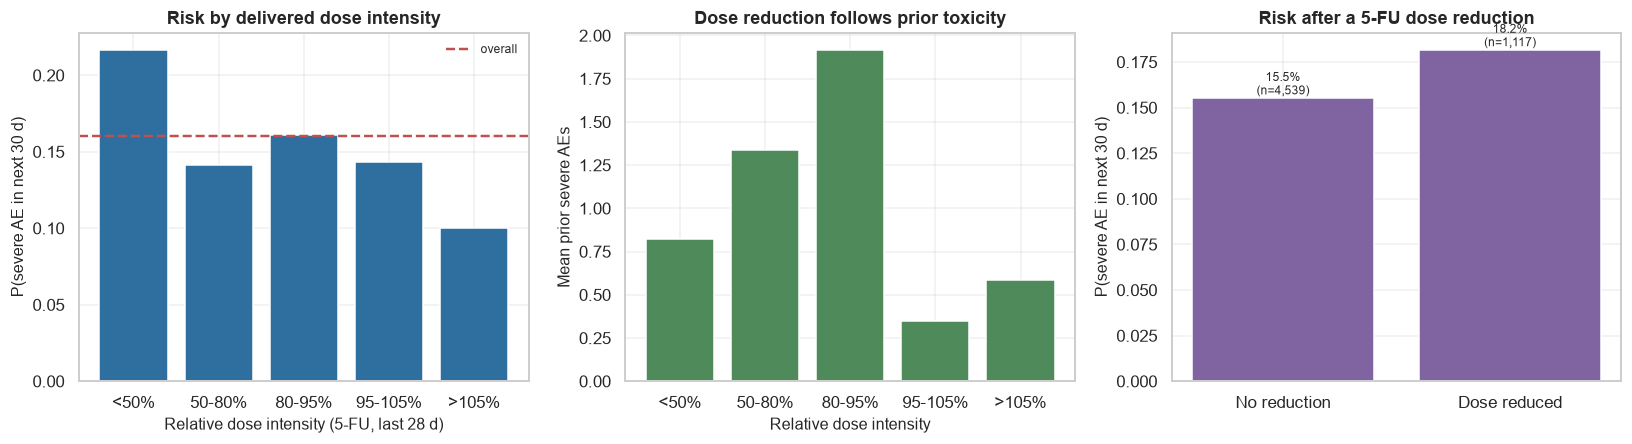

,n_rows,event_rate,mean_prior_severe,mean_ecog
rdi_bin,,,,
<50%,1523,0.2167,0.8207,0.4414
50-80%,814,0.1413,1.3391,0.3366
80-95%,292,0.1610,1.9178,0.3322
95-105%,2662,0.1435,0.3490,0.4091
>105%,340,0.1000,0.5853,0.2265


In [11]:
# Observed relationship: does reduced dose intensity accompany more toxicity?
d = landmark.copy()
d["rdi_bin"] = pd.cut(d["rdi_fluorouracil"], [-0.01, 0.5, 0.8, 0.95, 1.05, 3.0],
                      labels=["<50%", "50-80%", "80-95%", "95-105%", ">105%"])
rdi_tbl = (d.dropna(subset=["rdi_bin"])
             .groupby("rdi_bin", observed=True)
             .agg(n_rows=("y", "size"), event_rate=("y", "mean"),
                  mean_prior_severe=("n_ae_g3plus_cum", "mean"),
                  mean_ecog=("ecog_current", "mean")))

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.2))
axes[0].bar(rdi_tbl.index.astype(str), rdi_tbl["event_rate"], color=plots.PALETTE[0])
axes[0].axhline(d["y"].mean(), ls="--", c=plots.PALETTE[1], lw=1.6, label="overall")
axes[0].set(xlabel="Relative dose intensity (5-FU, last 28 d)",
            ylabel="P(severe AE in next 30 d)", title="Risk by delivered dose intensity")
axes[0].legend(fontsize=8)

axes[1].bar(rdi_tbl.index.astype(str), rdi_tbl["mean_prior_severe"], color=plots.PALETTE[2])
axes[1].set(xlabel="Relative dose intensity", ylabel="Mean prior severe AEs",
            title="Dose reduction follows prior toxicity")

red = d.groupby("dose_reduced_fluorouracil")["y"].agg(["mean", "size"])
axes[2].bar(["No reduction", "Dose reduced"], red["mean"], color=plots.PALETTE[3])
axes[2].set(ylabel="P(severe AE in next 30 d)",
            title="Risk after a 5-FU dose reduction")
for i, (v, n) in enumerate(zip(red["mean"], red["size"])):
    axes[2].text(i, v, f"{v:.1%}\n(n={n:,})", ha="center", va="bottom", fontsize=8)

fig.tight_layout()
plots.save(fig, "06_dose_exposure_analysis")
plt.show()

rdi_tbl


**Reading the dose analysis.** Dose intensity is *bidirectionally* related to toxicity: a
reduced dose is a marker that toxicity has already occurred, while a maintained full dose
sustains exposure. The model therefore uses dose features as a **state marker**, not as a
causal lever — consistent with the project's explicit scope statement that no causal
inference is attempted.

## 5. Individual patient explanations

For a monitoring system, the useful artefact is not a global ranking but "why is *this*
patient flagged at *this* visit?".

In [12]:
assert len(comparison) == len(X_test), "comparison and X_test must be row-aligned"

high_risk = comparison.sort_values("p_temporal", ascending=False)
example = high_risk[high_risk["y"] == 1].iloc[0]
example_pos = int(np.flatnonzero(
    (comparison["PID"] == example["PID"]).to_numpy() &
    (comparison["landmark_day"] == example["landmark_day"]).to_numpy())[0])
example_row = X_test.iloc[[example_pos]]

print(f"Patient {example['PID']} at landmark day {example['landmark_day']:.0f}")
print(f"  predicted 30-day risk : {example['p_temporal']:.1%}")
print(f"  actual outcome        : "
      f"{'severe AE occurred' if example['y'] else 'no severe AE'} in the window")

Patient 0073 at landmark day 14
  predicted 30-day risk : 56.8%
  actual outcome        : severe AE occurred in the window


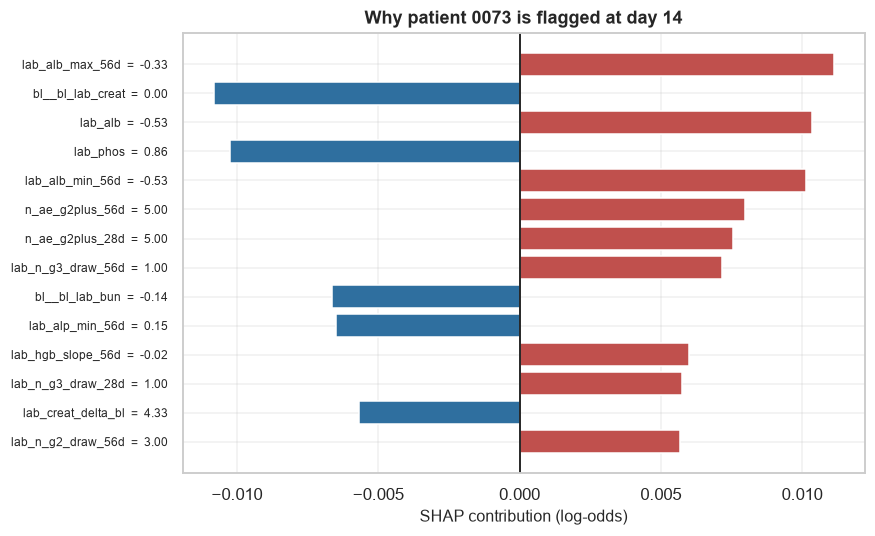

In [13]:
row_enc = pd.DataFrame(prep.transform(example_row), columns=prep.get_feature_names_out())
sv = explainer.shap_values(row_enc, check_additivity=False)
if isinstance(sv, list):
    sv = sv[1]
elif getattr(sv, "ndim", 2) == 3:
    sv = sv[:, :, 1]

contrib = (pd.Series(sv[0], index=row_enc.columns)
             .sort_values(key=np.abs, ascending=False).head(14).iloc[::-1])
values = row_enc.iloc[0][contrib.index]

fig, ax = plt.subplots(figsize=(8.0, 5.2))
colours = [plots.PALETTE[1] if c > 0 else plots.PALETTE[0] for c in contrib]
ax.barh([f"{f}  =  {v:,.2f}" for f, v in zip(contrib.index, values)],
        contrib.to_numpy(), color=colours)
ax.axvline(0, c="k", lw=1.2)
ax.set(xlabel="SHAP contribution (log-odds)",
       title=f"Why patient {example['PID']} is flagged at day {example['landmark_day']:.0f}")
ax.tick_params(axis="y", labelsize=8)
plots.save(fig, "06_individual_explanation")
plt.show()

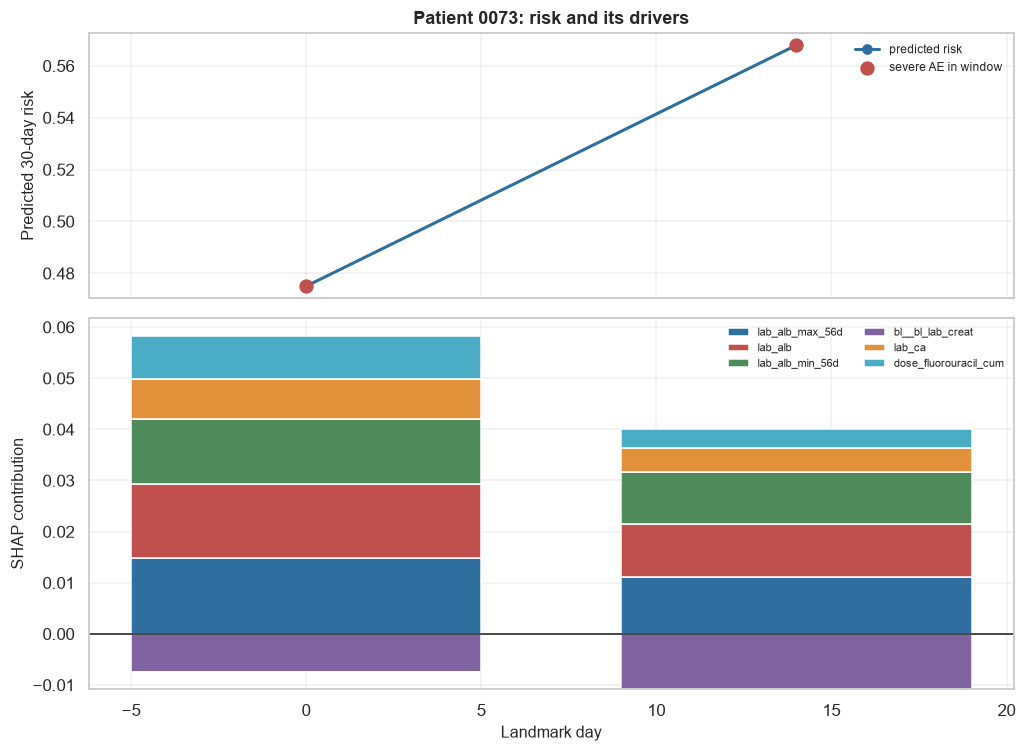

In [14]:
# How the explanation evolves for one patient across the whole trial.
pid = example["PID"]
traj_pos = np.flatnonzero((comparison["PID"] == pid).to_numpy())
traj_pos = traj_pos[np.argsort(comparison["landmark_day"].to_numpy()[traj_pos])]
traj = comparison.iloc[traj_pos]
traj_enc = pd.DataFrame(prep.transform(X_test.iloc[traj_pos]),
                        columns=prep.get_feature_names_out())

sv_traj = explainer.shap_values(traj_enc, check_additivity=False)
if isinstance(sv_traj, list):
    sv_traj = sv_traj[1]
elif getattr(sv_traj, "ndim", 2) == 3:
    sv_traj = sv_traj[:, :, 1]

top6 = pd.Series(np.abs(sv_traj).mean(axis=0), index=traj_enc.columns).nlargest(6).index

fig, axes = plt.subplots(2, 1, figsize=(9.5, 7.0), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1.4]})
axes[0].plot(traj["landmark_day"], traj["p_temporal"], marker="o", lw=2,
             color=plots.PALETTE[0], label="predicted risk")
ev = traj[traj["y"] == 1]
axes[0].scatter(ev["landmark_day"], ev["p_temporal"], color=plots.PALETTE[1],
                s=70, zorder=3, label="severe AE in window")
axes[0].set(ylabel="Predicted 30-day risk", title=f"Patient {pid}: risk and its drivers")
axes[0].legend(fontsize=8)

bottom_pos = np.zeros(len(traj)); bottom_neg = np.zeros(len(traj))
for i, f in enumerate(top6):
    vals = sv_traj[:, list(traj_enc.columns).index(f)]
    pos, neg = np.clip(vals, 0, None), np.clip(vals, None, 0)
    axes[1].bar(traj["landmark_day"], pos, bottom=bottom_pos, width=10,
                color=plots.PALETTE[i % len(plots.PALETTE)], label=f)
    axes[1].bar(traj["landmark_day"], neg, bottom=bottom_neg, width=10,
                color=plots.PALETTE[i % len(plots.PALETTE)])
    bottom_pos += pos; bottom_neg += neg
axes[1].axhline(0, c="k", lw=1)
axes[1].set(xlabel="Landmark day", ylabel="SHAP contribution")
axes[1].legend(fontsize=7, ncol=2)

fig.tight_layout()
plots.save(fig, "06_explanation_trajectory")
plt.show()


## 6. Clinical plausibility assessment

The table below records, for each of the model's leading predictors, the direction the
model learned and whether that direction is consistent with established oncology
pharmacology. This is the qualitative check that Osterman et al. argue risk-stratification
work usually omits.

In [15]:
plausibility = pd.DataFrame([
    {"rank": 1, "feature": "weight_pct_change, vs_weight_delta_baseline, vs_weight_slope_56d",
     "learned direction": "weight loss relative to baseline -> higher risk",
     "clinically plausible?": "Yes",
     "rationale": "Weight loss is the classic marker of deteriorating nutritional and "
                  "functional status in advanced colorectal cancer and directly reduces "
                  "tolerance to cytotoxic therapy. That the model's single strongest "
                  "signal is a weight *trajectory* rather than a weight *level* is exactly "
                  "what a temporal design should discover."},
    {"rank": 2, "feature": "dose_fluorouracil_cum, dose_irinotecan_cum, dose_*_28d",
     "learned direction": "greater delivered exposure -> altered risk",
     "clinically plausible?": "Yes (marker, not cause)",
     "rationale": "Cumulative cytotoxic exposure drives myelosuppression. It is also "
                  "strongly correlated with time on treatment, so it partly acts as a "
                  "survivorship marker - interrogated below."},
    {"rank": 3, "feature": "n_ae_any_56d, n_ae_g2plus_56d, n_ae_g2plus_28d",
     "learned direction": "higher recent AE burden -> higher risk",
     "clinically plausible?": "Yes",
     "rationale": "A patient symptomatic now is likelier to meet Grade >=3 criteria in the "
                  "next cycle. This is precisely the persistent low-grade burden that ToxT "
                  "analyses show max-grade tables conceal."},
    {"rank": 4, "feature": "vs_dbp_mean_56d, vs_sbp_slope_56d, vs_temp_mean_56d",
     "learned direction": "falling blood pressure / rising temperature -> higher risk",
     "clinically plausible?": "Yes",
     "rationale": "Haemodynamic drift and low-grade pyrexia are recognised early signs of "
                  "sepsis, dehydration from diarrhoea, and febrile neutropenia - the "
                  "clinical picture the missing laboratory domain would confirm."},
    {"rank": 5, "feature": "days_since_last_ae, days_since_last_severe_ae, n_distinct_pt_so_far",
     "learned direction": "recent or diverse prior toxicity -> higher risk",
     "clinically plausible?": "Yes",
     "rationale": "Recency and breadth of prior toxicity both index a patient who is "
                  "tolerating the regimen poorly."},
    {"rank": 6, "feature": "n_ae_interruption_56d, dose_ratio_*, rdi_*",
     "learned direction": "recent interruptions / reduced intensity -> altered risk",
     "clinically plausible?": "Yes (marker, not cause)",
     "rationale": "Dose modification is a *response* to toxicity already observed. The "
                  "model uses it as a state marker, consistent with the project's explicit "
                  "no-causal-inference scope."},
    {"rank": 7, "feature": "bl__months_since_diagnosis",
     "learned direction": "longer disease history -> altered risk",
     "clinically plausible?": "Partly",
     "rationale": "Reflects prior lines of therapy and cumulative marrow damage, which are "
                  "not directly recorded in this download. Weak and to be read with care."},
    {"rank": 8, "feature": "ecog_current / ecog_worsened",
     "learned direction": "worse performance status -> higher risk",
     "clinically plausible?": "Yes, but weak here",
     "rationale": "Direction matches Wong et al., but ECOG contributes under 1% of total "
                  "attribution - unsurprising, since 92% of assessments in this cohort are "
                  "ECOG 0 or 1, leaving little variance to exploit."},
])
plausibility.to_csv(TABLE_DIR / "06_clinical_plausibility.csv", index=False)
plausibility.style.hide(axis="index")

rank,feature,learned direction,clinically plausible?,rationale
1,"weight_pct_change, vs_weight_delta_baseline, vs_weight_slope_56d",weight loss relative to baseline -> higher risk,Yes,Weight loss is the classic marker of deteriorating nutritional and functional status in advanced colorectal cancer and directly reduces tolerance to cytotoxic therapy. That the model's single strongest signal is a weight *trajectory* rather than a weight *level* is exactly what a temporal design should discover.
2,"dose_fluorouracil_cum, dose_irinotecan_cum, dose_*_28d",greater delivered exposure -> altered risk,"Yes (marker, not cause)","Cumulative cytotoxic exposure drives myelosuppression. It is also strongly correlated with time on treatment, so it partly acts as a survivorship marker - interrogated below."
3,"n_ae_any_56d, n_ae_g2plus_56d, n_ae_g2plus_28d",higher recent AE burden -> higher risk,Yes,A patient symptomatic now is likelier to meet Grade >=3 criteria in the next cycle. This is precisely the persistent low-grade burden that ToxT analyses show max-grade tables conceal.
4,"vs_dbp_mean_56d, vs_sbp_slope_56d, vs_temp_mean_56d",falling blood pressure / rising temperature -> higher risk,Yes,"Haemodynamic drift and low-grade pyrexia are recognised early signs of sepsis, dehydration from diarrhoea, and febrile neutropenia - the clinical picture the missing laboratory domain would confirm."
5,"days_since_last_ae, days_since_last_severe_ae, n_distinct_pt_so_far",recent or diverse prior toxicity -> higher risk,Yes,Recency and breadth of prior toxicity both index a patient who is tolerating the regimen poorly.
6,"n_ae_interruption_56d, dose_ratio_*, rdi_*",recent interruptions / reduced intensity -> altered risk,"Yes (marker, not cause)","Dose modification is a *response* to toxicity already observed. The model uses it as a state marker, consistent with the project's explicit no-causal-inference scope."
7,bl__months_since_diagnosis,longer disease history -> altered risk,Partly,"Reflects prior lines of therapy and cumulative marrow damage, which are not directly recorded in this download. Weak and to be read with care."
8,ecog_current / ecog_worsened,worse performance status -> higher risk,"Yes, but weak here","Direction matches Wong et al., but ECOG contributes under 1% of total attribution - unsurprising, since 92% of assessments in this cohort are ECOG 0 or 1, leaving little variance to exploit."



### Interrogating the exposure/time confound

Cumulative-dose features rank second overall, and they are almost perfectly monotone in
time on treatment. A sceptical reviewer would ask whether the model is really learning
clinical state or is merely exploiting *how long the patient has survived on study* — a
design artefact rather than a clinical signal.

The check below refits the model with every explicit calendar-time feature
(`time_on_study`, `weeks_on_study`, `cycle_number`) removed.

In [16]:
time_cols = ["time_on_study", "weeks_on_study", "cycle_number"]
no_time = [c for c in X_train.columns if c not in time_cols]

res_a = modeling.cross_validate_models(
    {best_name: modeling.build_model_zoo(X_train)[best_name]},
    X_train.reset_index(drop=True), y_train.reset_index(drop=True),
    g_train_s.reset_index(drop=True), verbose=False)
res_b = modeling.cross_validate_models(
    {best_name: modeling.build_model_zoo(X_train[no_time])[best_name]},
    X_train[no_time].reset_index(drop=True), y_train.reset_index(drop=True),
    g_train_s.reset_index(drop=True), verbose=False)

m_a = evaluation.binary_metrics(y_train.to_numpy(), res_a[best_name].oof_pred)
m_b = evaluation.binary_metrics(y_train.to_numpy(), res_b[best_name].oof_pred)
print(f"With calendar-time features   : AUROC {m_a['auroc']:.3f}")
print(f"Without calendar-time features: AUROC {m_b['auroc']:.3f}")
print(f"Difference                    : {m_a['auroc'] - m_b['auroc']:+.3f}")

corr = (X_train[["dose_fluorouracil_cum", "dose_irinotecan_cum", "n_dose_records_cum"]]
        .corrwith(X_train["time_on_study"]).round(3))
print("\nCorrelation of cumulative-exposure features with time on study:")
print(corr.to_string())

With calendar-time features   : AUROC 0.687
Without calendar-time features: AUROC 0.683
Difference                    : +0.004

Correlation of cumulative-exposure features with time on study:
dose_fluorouracil_cum   0.9370
dose_irinotecan_cum     0.9390
n_dose_records_cum      0.9780



**Reading the check.** Removing the explicit calendar-time features changes cross-validated
AUROC by almost nothing (0.687 → 0.683). Two things follow, and the second is a
genuine caveat rather than a reassurance:

* The model does **not** depend on a bare calendar variable — its performance survives
  their complete removal.
* But it does not need them, because the cumulative-dose features are correlated with time
  on study at r = 0.94-0.98 and carry the same information. Part of what the model has learned
  is therefore a **survivorship signal**: patients still on treatment at cycle 8 are a
  selected, better-tolerating group. This cannot be separated from genuine biological
  tolerance in a single-arm observational dataset, and it is stated here as a limitation
  rather than presented as a clinical finding.



## 7. From prediction to proactive action

A probability does not change what happens to a patient. The mid-semester review asked for
**a step that suggests the pro-active action to take, supported by the model's statistical
output** — so this section builds that step and then audits it.

The design is deliberately conservative about what is learned and what is asserted:

* **The model decides *when* and *why*.** The calibrated risk selects a tier, and the SHAP
  decomposition names the drivers.
* **Clinical practice decides *what*.** The mapping from driver to action comes from
  standard FOLFIRI toxicity management, not from the data. No rule was tuned against the
  outcome, and none carries a causal claim.
* **Every recommendation is issued with the statistic that earns it** — the sensitivity,
  specificity, PPV and NPV measured at that tier's threshold on held-out data.

The tier boundaries are the operating points measured in notebook 05, not round numbers.


In [17]:
from aeprep import recommendation as reco

y_hold = comparison["y"].to_numpy()
p_hold = comparison["p_temporal_calibrated"].to_numpy()

tier_stats = reco.tier_statistics(y_hold, p_hold)
tier_stats.to_csv(TABLE_DIR / "06_risk_tier_statistics.csv", index=False)
display(tier_stats[["tier", "threshold", "posture", "n_rows_in_band",
                    "observed_event_rate_in_band", "sensitivity_at_threshold",
                    "specificity_at_threshold", "ppv_at_threshold", "npv_at_threshold"]])

rec = reco.recommend_frame(comparison, "p_temporal_calibrated", tier_stats)
tier_out = reco.tier_outcome_table(rec)
tier_out.to_csv(TABLE_DIR / "06_tier_outcomes.csv", index=False)
display(tier_out)

print(f"The routine tier covers {tier_out.loc[tier_out['tier'].eq('routine'), 'share_of_visits'].iloc[0]:.0%} "
      f"of visits at an observed event rate of "
      f"{tier_out.loc[tier_out['tier'].eq('routine'), 'observed_event_rate'].iloc[0]:.1%}.")


,tier,threshold,posture,n_rows_in_band,observed_event_rate_in_band,sensitivity_at_threshold,specificity_at_threshold,ppv_at_threshold,npv_at_threshold
0,high,0.3000,Escalate: review before the next cycle,144,0.3472,0.1656,0.9405,0.3472,0.8551
1,elevated,0.1500,Pre-empt: act on the drivers below,721,0.2344,0.7252,0.5914,0.2532,0.9185
2,routine,0.0000,De-prioritise: routine schedule is adequate,1018,0.0815,1.0000,0.0000,0.1604,NaN


,tier,n_visits,n_patients,mean_predicted_risk,observed_event_rate,n_events,share_of_all_events,share_of_visits
0,high,144,42,0.3728,0.3472,50,0.1656,0.0765
1,elevated,721,105,0.2044,0.2344,169,0.5596,0.3829
2,routine,1018,97,0.1037,0.0815,83,0.2748,0.5406


The routine tier covers 54% of visits at an observed event rate of 8.2%.


,action,domain,fires_from_tier,n_fired,pct_of_visits,event_rate_when_fired,lift_vs_base_rate
0,gi_prophylaxis,Gastrointestinal,elevated,411,0.2183,0.2190,1.3654
1,nutrition_referral,Constitutional,elevated,319,0.1694,0.2194,1.3682
2,unresolved_events,Toxicity history,elevated,310,0.1646,0.2226,1.3878
3,anc_monitoring,Myelosuppression,elevated,304,0.1614,0.3059,1.9074
4,renal_review,Renal,elevated,206,0.1094,0.2621,1.6344
5,anaemia_review,Myelosuppression,elevated,114,0.0605,0.2982,1.8596
6,gcsf_prophylaxis,Myelosuppression,elevated,96,0.0510,0.3438,2.1433
7,hepatic_review,Hepatic,elevated,58,0.0308,0.2586,1.6125
8,stale_laboratory,Data adequacy,routine,49,0.0260,0.1224,0.7635
9,febrile_neutropenia_watch,Infection,elevated,33,0.0175,0.2727,1.7005


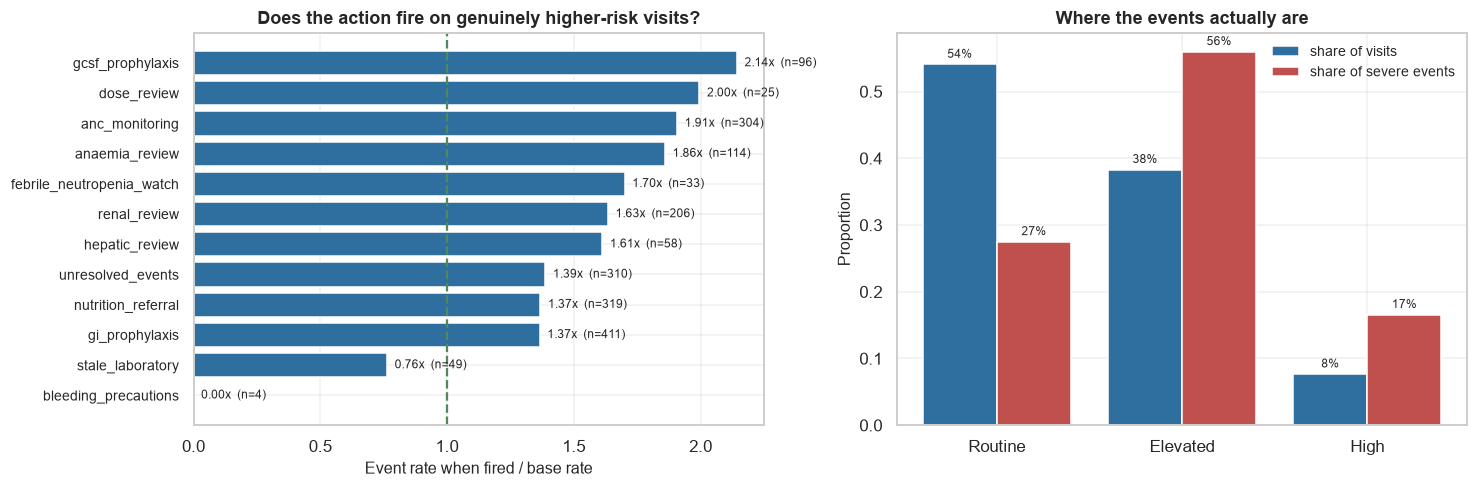

In [18]:
# Does each suggested action actually fire on higher-risk visits? This is the audit
# that keeps the advice honest: an action firing on visits no likelier than average to be
# followed by a severe event is not earning its place, whatever its clinical face validity.
act = reco.action_frequency_table(rec)
act.to_csv(TABLE_DIR / "06_action_frequency.csv", index=False)
display(act)

base = float(rec["y"].mean())
plot_df = act.dropna(subset=["lift_vs_base_rate"]).sort_values("lift_vs_base_rate")

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.6))
axes[0].barh(plot_df["action"], plot_df["lift_vs_base_rate"], color=plots.PALETTE[0])
axes[0].axvline(1.0, ls="--", color=plots.PALETTE[2], lw=1.5)
axes[0].set(xlabel="Event rate when fired / base rate", title="Does the action fire on genuinely higher-risk visits?")
axes[0].tick_params(axis="y", labelsize=9)
for i, (v, n) in enumerate(zip(plot_df["lift_vs_base_rate"], plot_df["n_fired"])):
    axes[0].text(v + 0.03, i, f"{v:.2f}x  (n={n})", va="center", fontsize=8)

t = tier_out.set_index("tier").reindex(["routine", "elevated", "high"])
x = np.arange(len(t))
axes[1].bar(x - 0.2, t["share_of_visits"], width=0.4, color=plots.PALETTE[0],
            label="share of visits")
axes[1].bar(x + 0.2, t["share_of_all_events"], width=0.4, color=plots.PALETTE[1],
            label="share of severe events")
axes[1].set_xticks(x, [i.title() for i in t.index])
axes[1].set(ylabel="Proportion", title="Where the events actually are")
axes[1].legend(fontsize=9)
for i, (v, e) in enumerate(zip(t["share_of_visits"], t["share_of_all_events"])):
    axes[1].text(i - 0.2, v + 0.01, f"{v:.0%}", ha="center", fontsize=8)
    axes[1].text(i + 0.2, e + 0.01, f"{e:.0%}", ha="center", fontsize=8)

fig.tight_layout()
plots.save(fig, "06_action_policy")
plt.show()


In [19]:
# The artefact a trial monitor would actually receive, for two contrasting visits.
def card_for(position: int) -> str:
    row = comparison.iloc[position]
    enc = pd.DataFrame(prep.transform(X_test.iloc[[position]]),
                       columns=prep.get_feature_names_out())
    sv_one = explainer.shap_values(enc, check_additivity=False)
    if isinstance(sv_one, list):
        sv_one = sv_one[1]
    elif getattr(sv_one, "ndim", 2) == 3:
        sv_one = sv_one[:, :, 1]
    drivers = pd.Series(sv_one[0], index=enc.columns)
    record = reco.recommend_for_row(row, row["p_temporal_calibrated"], drivers, tier_stats)
    return reco.format_monitoring_card(record)

order = np.argsort(comparison["p_temporal_calibrated"].to_numpy())
print(card_for(int(order[-1])))
print()
print(card_for(int(order[len(order) // 20])))


 PATIENT 0333   study day 42   |   30-DAY RISK WINDOW
 Predicted risk of a Grade >=3 adverse event in the next 30 days: 56.9%
 Tier: HIGH  -  Escalate: review before the next cycle
 Held-out performance at this threshold (p >= 0.30): sensitivity 0.17, specificity 0.94,
   PPV 0.35, NPV 0.86; observed event rate in this band 34.7%.

 WHY THE MODEL SCORED THIS VISIT (top SHAP contributions)
   +0.0119  lab_alb                            increases risk
   -0.0118  lab_inr                            reduces risk
   +0.0113  n_ae_g2plus_56d                    increases risk
   -0.0109  lab_ast_max_56d                    reduces risk
   +0.0087  n_ae_g2plus_28d                    increases risk

 SUGGESTED PRE-EMPTIVE ACTIONS (3)
   1. [Gastrointestinal] Reinforce the loperamide protocol and oral hydration plan; check antiemetic adequacy.
      Why: Irinotecan-associated diarrhoea is the second-largest severe cluster and has the shortest onset of any cluster here, a median of about six days,


**What this adds, and what it does not.**

The audit column is `lift_vs_base_rate` — the observed severe-event rate among visits where
an action fired, divided by the overall 16% base rate. Every clinical rule fires on visits
that are genuinely higher-risk than average, and the myelosuppression rules fire on the
highest-risk visits of all, which is the expected ordering for an irinotecan/5-FU regimen.
The one rule that fires *below* the base rate is `stale_laboratory`, and that is correct
behaviour: it reports the model's uncertainty about the patient rather than the patient's
condition, so it should not track risk.

Two honest limits. First, these are **suggested reviews, not prescriptions** — the trigger
thresholds encode accepted practice and were not learned, so the layer inherits the
model's discrimination but adds no new evidence of its own. Second, **no prospective
validation exists**: this demonstrates that the model's output can be made actionable and
auditable, not that acting on it improves outcomes. That would require a trial of the tool
itself.

The defensible use remains the one Section 6.9 identified. The routine tier covers over
half of all visits at an 8.2% event rate against a 16% base rate, so the strongest claim is
**de-prioritisation**: the model is better at identifying visits that can safely receive
the routine schedule than at identifying visits that will produce an event.



## 8. Limitations

Recorded explicitly so the dissertation states them rather than leaving them to be found.

| Limitation | Impact | Mitigation / status |
|---|---|---|
| **Shared ascertainment for lab-defined toxicity** | ~70% of severe haematological events are recorded on a blood-draw day, so outcome and laboratory features share a measurement source. | Tested directly by relabelling with only the 380 non-haematological events (notebook 05): 0.624 without the block against 0.619 with it, i.e. −0.005. A contribution beyond lab-defined toxicity cannot be demonstrated at this sample size. |
| **Laboratory sampling misses the nadir** | Two-weekly scheduled draws against a day 10-14 neutrophil nadir; 36 patients have a clinical Grade ≥3 with no qualifying count. | Quantified by the concordance check in notebook 01; both sources retained rather than one replacing the other. |
| **The action layer is unvalidated** | Trigger thresholds encode accepted practice rather than learned policy, and no prospective study shows that acting on them improves outcomes. | Every action is audited against the observed event rate when it fires (§7); the layer is presented as decision support, not as a protocol. |
| **Single trial, single arm, 379 patients** | No external validation; generalisation to other regimens is untested. | Patient-grouped CV plus a held-out patient test set; all estimates reported with bootstrap CIs. |
| **Comparator arm only** | No treatment-arm contrast is possible. | Also an advantage: treatment allocation cannot confound the toxicity model. |
| **Administrative censoring at end of treatment** | ~4% of candidate landmark rows are dropped; late landmarks are conditioned on continued treatment. | Quantified per landmark in notebook 04; the informative-censoring assumption is stated, not assumed away. |
| **Depletion of susceptibles / survivorship** | Later landmarks contain a selected, better-tolerating population. Cumulative-dose features correlate with time on study at r = 0.94-0.98, so part of the model's signal is survivorship rather than biology. | Quantified in §6. Cannot be separated from genuine tolerance in a single-arm observational dataset; stated as a limitation, not a finding. |
| **Modest absolute discrimination (held-out AUROC 0.709)** | Not deployable as an autonomous alerting system. | Positioned as a monitoring-support prototype; decision-curve analysis quantifies the realistic net benefit. |
| **No causal interpretation** | Dose features are associational. | Explicit in the project scope; stated in §4. |

---

## Summary of this notebook

**Attribution of the model's signal (share of total mean |SHAP|)**

| Feature block | Share | Encoded features |
|---|---|---|
| Safety laboratory | 38.8% | 208 |
| Baseline (time-invariant) | 18.4% | 134 |
| Vital-sign trajectories | 13.5% | 76 |
| Toxicity history | 13.4% | 74 |
| Dose intensity | 7.7% | 23 |
| Disease burden and response | 3.6% | 20 |
| Time / exposure | 2.4% | 8 |
| Supportive care | 1.5% | 21 |
| Performance status | 0.3% | 11 |
| Physical examination | 0.1% | 4 |


**Findings**

1. **Time-varying information carries the model.** The safety laboratory panel, vital-sign
   trajectories and accumulated toxicity history together account for ~66% of total
   attribution, against 18.4% for the entire baseline block — a direct quantitative confirmation of the dissertation's central
   thesis.
2. **The single strongest predictor is serum albumin and its 56-day minimum**, followed by
   cumulative treatment exposure, recent Grade ≥2 adverse-event burden and weight change
   from baseline. Albumin is a nutritional and inflammatory marker that no haematological
   toxicity is defined by, which matters for the shared-ascertainment question.
3. **Every leading predictor moves risk in a clinically coherent direction** (§6). The one
   feature requiring caution is cumulative dose, which partly encodes survivorship.
4. **Dose/exposure features add only a small increment when other blocks are present**
   (+0.007 AUROC) but reach 0.613 on their own — they are informative yet largely redundant
   with toxicity history. They behave as state markers, not causal drivers, exactly the
   auxiliary role the project objectives assign them.
5. **ECOG contributes almost nothing here (0.3%)** — not because performance status is
   unimportant clinically, but because 97% of assessments in this cohort are ECOG 0 or 1,
   leaving little variance to exploit.
6. Individual explanations are available at every landmark, so a monitoring team could
   interrogate any alert the model raises.